In [4]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_circuit_lr2

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


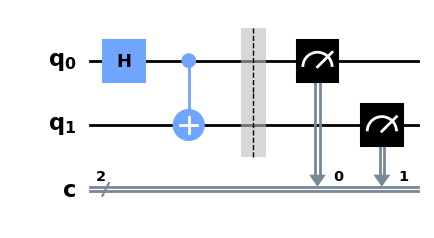

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
import numpy as np
import matplotlib.pyplot as plt

# 1. Create the Bell state (|ψ⟩ = (|00⟩ + |11⟩)/√2)
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()

# 2. Define measurement bases (for a simple Bell test, we'll use the Z basis for both qubits)
# In a more complex Bell test, you would rotate the measurement bases.
qc.measure([0, 1], [0, 1])

# 3. Simulate the circuit for 1024 shots
simulator = BasicSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(qc)
qc.draw(output="mpl", style="clifford", fold=40)

In [ ]:

# 4. Ensure all four outcomes are present in the counts (even if zero)
all_outcomes = ['00', '01', '10', '11']
histogram_data = {outcome: counts.get(outcome, 0) for outcome in all_outcomes}

# 5. Print the histogram data
print("Histogram of Measurement Outcomes (1024 Events):")
print(histogram_data)

# 6. Plot the Quantum Circuit
circuit_diagram = plot_circuit_diagram(qc, output='text') #Changed output to text
print(circuit_diagram)

# Optional: Visualize the histogram
labels = histogram_data.keys()
values = histogram_data.values()

plt.bar(labels, values)
plt.xlabel("Measurement Outcomes")
plt.ylabel("Number of Events")
plt.title("Bell State Measurement Simulation (1024 Shots)")
plt.show()
